---
title: CMMTE Comparisons
date: 02/2026
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

First, let's load up a csv table of with count and duration information for CMMTEs across the various regions of Antarctica, for each month of each year from 1992-2012. This table was extracted from the CMMT Excel spreadsheets, provided by Jonathan Chambers and Matthew Lazzara.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from artools.loading_utils import *
from artools.attribute_utils import *
from artools.format_utils import *
from artools.display_utils import *

/home/jovyan/antarctic_AR_dataset/notebooks/quality_assurance


In [2]:
# loading up the CMMTE data
cmmtes = pd.read_csv('../input_data/cmmte/cmmte_regional_counts_durations.csv')
cmmtes['count'] = cmmtes.iloc[:,-12:].sum(1)

FileNotFoundError: [Errno 2] No such file or directory: '../input_data/cmmte/cmmte_regional_counts_durations.csv'

In [55]:
# loading up the catalogs and doing some light preprocessing
ais_da = load_ais('../input_data/antarctic_masks/')

full_cat = pd.read_hdf('../catalogs/official/epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
landfalling_storms = full_cat[full_cat.is_landfalling]

landfalling_storms['start_date'] = landfalling_storms['data_array'].apply(add_start_date, ais_da=ais_da)
landfalling_storms['end_date'] = landfalling_storms['data_array'].apply(add_end_date, ais_da=ais_da)
landfalling_storms['landfall_duration'] = landfalling_storms['data_array'].apply(compute_duration, ais_da=ais_da)
landfalling_storms['full_duration'] = landfalling_storms['data_array'].apply(compute_duration)

## Aggregate Statistics

In [64]:
yearly_cmmtes = cmmtes.groupby('Year')['count'].sum()
yearly_cmmtes = yearly_cmmtes.loc[1993:2012] 
yearly_ars = landfalling_storms.groupby(landfalling_storms['start_date'].dt.year).size()
yearly_ars = yearly_ars.loc[1993:2012]

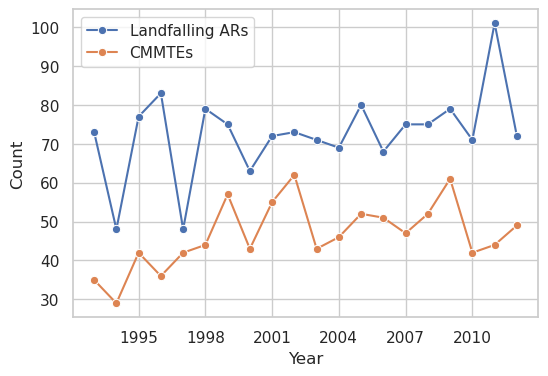

In [66]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.lineplot(x=yearly_ars.index.astype(int), 
             y=yearly_ars.values, 
             marker='o', 
             label='Landfalling ARs')

sns.lineplot(x=yearly_cmmtes.index.astype(int), 
             y=yearly_cmmtes.values, 
             marker='o', 
             label='CMMTEs')

# Axis Labeling
plt.xlabel('Year')
plt.ylabel('Count')

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))


plt.legend()
plt.savefig('../output/count_comparisons.png', dpi=300)

## Individual Event Comparisons

In [ ]:
storms2009 = landfalling_storms[landfalling_storms.end_date.dt.year == 2009]

In [ ]:
stormtime = to_stormtime_format(storms2009)

In [ ]:
animation = make_movie(stormtime, '2009 Storms', '../output/2009_storms.mp4')

In [ ]:
from IPython.display import Video
Video("../output/2009_storms.mp4")